# Predicting pit stop from stint number, tyre, and other data

This is my attempt at predicting whether a driver will need to make a pit stop in the next lap for the "Predicting F1 Pit Stops" playground competition on Kaggle (Yao Yan, Walter Reade, Elizabeth Park. Predicting F1 Pit Stops. https://kaggle.com/competitions/playground-series-s6e5, 2026. Kaggle.) This competition uses synthetic data inspired by the "F1 Strategy Dataset" at https://www.kaggle.com/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/data. First let's take a look at the data.

In [20]:
from setup import *
source = pd.read_csv('../data/train.csv')
source.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## First take
### Low-hanging fruit
TyreLife should be strongly correlated with the target variable. Compound may directly affect the TyreLife value at which a pit stop is warranted. Cumulative_Degradation should similarly have a strong relationship to the target. PitStop is presumably negatively correlated with PitNextLap. 
### Driver strategy
Whether to make a pit stop has much to do with the driver's strategy, and there may be traces of this in the data. For instance, if most of the drivers are going slow, a pit stop costs less. So a feature accumulating LapTimes in the same lap for different drivers might tell us something about the likelihood of a driver making a pit stop. The driver's own laptime_delta might also be somewhat indicative of favorable conditions for a pitstop.
### Environment
Important information like the temperature is missing. Perhaps this information is recoverable in Year and Race.

In [200]:
# First, let's clean it up a little so we can look at relationships.
driver_enc = OrdinalEncoder(categories='auto')
source["Driver_encoded"] = driver_enc.fit_transform(source[["Driver"]])
race_enc = OrdinalEncoder(categories='auto')
source["Race_encoded"] = race_enc.fit_transform(source[["Race"]])
source["RaceProgress_binned"] = pd.cut(source["RaceProgress"],bins=10, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
prog_enc = OrdinalEncoder(categories='auto')
compound_enc = OneHotEncoder(handle_unknown='ignore', categories='auto')
compound_cols = compound_enc.fit_transform(source[["Compound"]])
compound_cols = pd.DataFrame.sparse.from_spmatrix(compound_cols)
compound_headers = np.sort(source["Compound"].unique())
compound_cols = compound_cols.rename(columns={
    0: compound_headers[0],
    1: compound_headers[1],
    2: compound_headers[2],
    3: compound_headers[3],
    4: compound_headers[4]
})

F1_clean = pd.concat([source, compound_cols], axis=1)
F1_clean = F1_clean.drop(columns = ["Race", "Driver","Compound"])


In [201]:
F1_clean.head()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,...,Position_Change,PitNextLap,Driver_encoded,Race_encoded,RaceProgress_binned,HARD,INTERMEDIATE,MEDIUM,SOFT,WET
0,0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,...,5.0,1.0,134.0,7.0,7,1.0,0,0,0,0
1,1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,...,-3.0,0.0,111.0,9.0,3,1.0,0,0,0,0
2,2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,...,3.0,1.0,886.0,2.0,8,1.0,0,0,0,0
3,3,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,...,0.0,0.0,864.0,19.0,0,0,0,1.0,0,0
4,4,2022,1,26,3,6.0,2,107.878,8.965,-14.139,...,3.0,0.0,44.0,3.0,3,1.0,0,0,0,0


<Axes: >

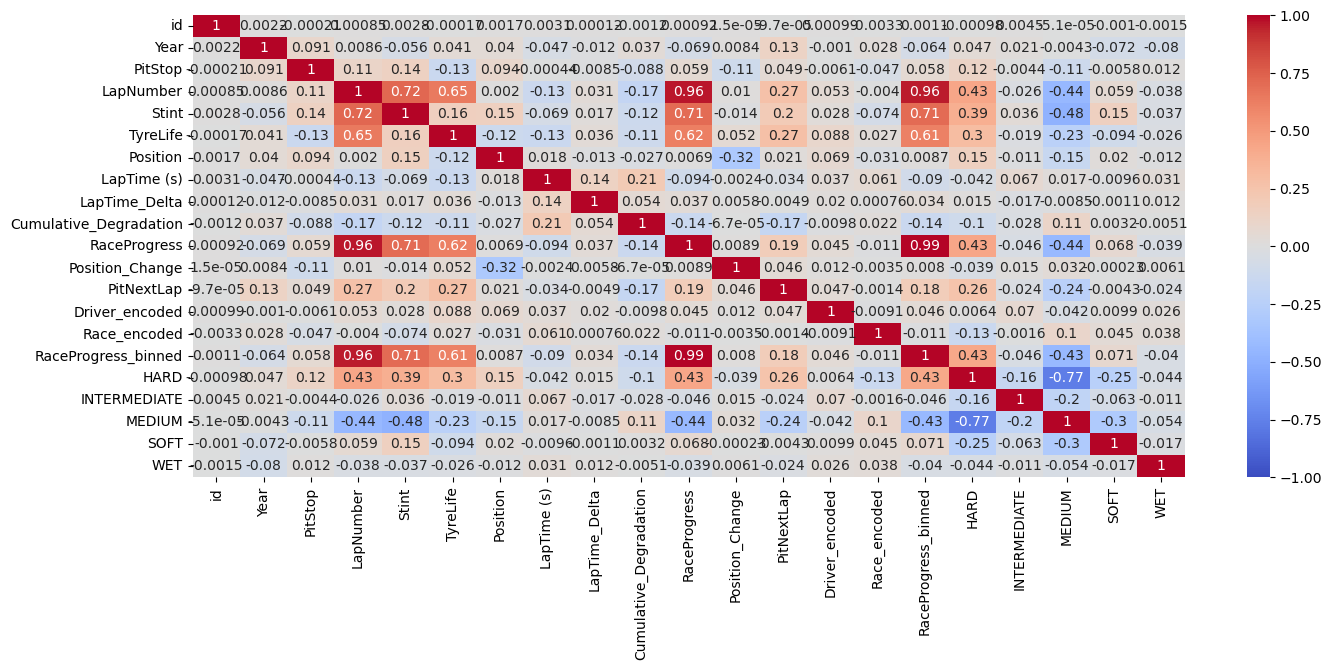

In [202]:
# Let's make a heatmap showing correlations.
plt.figure(figsize=(16, 6))
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(F1_clean.corr(), cmap="coolwarm", vmin=-1, vmax=1, annot=True)

Tyrelife has a 0.27 correlation with the target. Hard and Medium are correlated at 0.26 and -0.24 with the target. I would have expected Hard to have a negative correlation, since it is more durable than the other types. However, Hard is positively correlated with RaceProgress, and so is the target. For some reason, drivers are more likely to drive on hard tires as the race goes on, and they're more likely to make frequent pit stops. Cumulative_Degeneration is slightly negatively correlated with the target, another surprise. Just out of curiousity, let's take a look at real data. 

In [204]:
# Preprocess the natural F1 data the same way so we can compare some of 
# the relationships there.

natural_data = pd.read_csv('../data/f1_strategy_dataset_v4.csv')

driver_enc = OrdinalEncoder(categories='auto')
natural_data["Driver_encoded"] = driver_enc.fit_transform(natural_data[["Driver"]])
race_enc = OrdinalEncoder(categories='auto')
natural_data["Race_encoded"] = race_enc.fit_transform(natural_data[["Race"]])
natural_data["RaceProgress_binned"] = pd.cut(natural_data["RaceProgress"],bins=10, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

# There are some nan's in the natural data
natural_data["Compound"] = np.where(natural_data["Compound"].isnull(), "MEDIUM", natural_data["Compound"])
compound_enc = OneHotEncoder(handle_unknown='ignore', categories='auto')
compound_cols = compound_enc.fit_transform(natural_data[["Compound"]])
compound_cols = pd.DataFrame.sparse.from_spmatrix(compound_cols)
compound_headers = np.sort(natural_data["Compound"].unique())

compound_cols = compound_cols.rename(columns={
    0: compound_headers[0],
    1: compound_headers[1],
    2: compound_headers[2],
    3: compound_headers[3],
    4: compound_headers[4]
})
natural_clean = pd.concat([natural_data, compound_cols], axis=1)
natural_clean = natural_clean.drop(columns = ["Race", "Driver","Compound"])

In [205]:
natural_clean.head()

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,...,Normalized_TyreLife,Position_Change,Driver_encoded,Race_encoded,RaceProgress_binned,HARD,INTERMEDIATE,MEDIUM,SOFT,WET
0,1,1,2,17,100.625,2023,0.000,0.000,0,0,...,0.117647,0,0.0,0.0,0,0,0,1.0,0,0
1,2,1,3,18,93.560,2023,-7.065,-7.065,0,0,...,0.176471,-1,0.0,0.0,0,0,0,1.0,0,0
2,3,1,4,18,91.768,2023,-1.792,-8.857,0,0,...,0.235294,0,0.0,0.0,0,0,0,1.0,0,0
3,4,1,5,18,91.591,2023,-0.177,-9.034,0,0,...,0.294118,0,0.0,0.0,0,0,0,1.0,0,0
4,5,1,6,18,91.422,2023,-0.169,-9.203,0,0,...,0.352941,0,0.0,0.0,0,0,0,1.0,0,0


<Axes: >

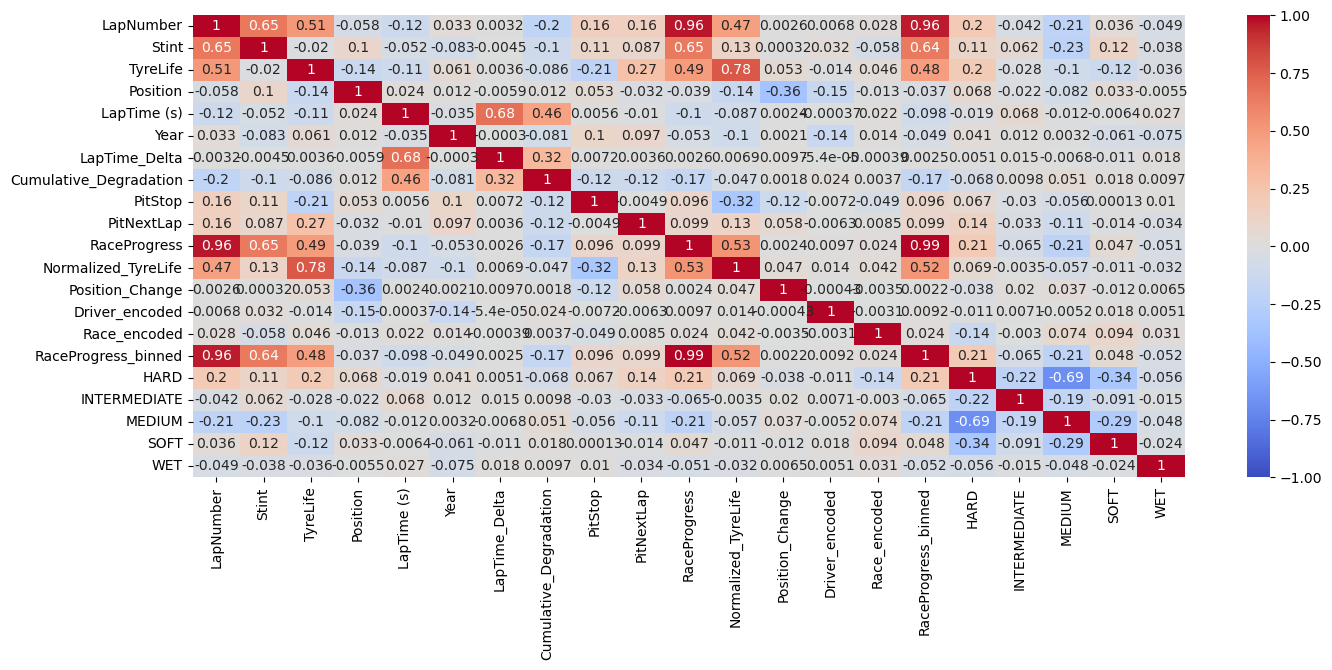

In [206]:
# Let's make a heatmap showing correlations.
plt.figure(figsize=(16, 6))
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(natural_clean.corr(), cmap="coolwarm", vmin=-1, vmax=1, annot=True)

The pattern holds, although the correlations are weaker in the natural data. 

In [207]:
for compound in ["HARD", "INTERMEDIATE", "MEDIUM", "SOFT", "WET"]:
    print(f"{compound}: {natural_clean.groupby([compound]).agg({'RaceProgress': 'mean'}).iloc[1,0]}")

HARD: 0.4932965958601323
INTERMEDIATE: 0.36346276991370563
MEDIUM: 0.3618358090840343
SOFT: 0.46463887816816984
WET: 0.22332114683717633


In [208]:
natural_clean["RaceProgress"].describe()

count    101371.000000
mean          0.432618
std           0.258129
min           0.012821
25%           0.210526
50%           0.421053
75%           0.631579
max           1.000000
Name: RaceProgress, dtype: float64

HARD and MEDIUM have above average RaceProgress values, suggesting they both tend to be used later in the race. 

In [232]:
# Add Mean_lap_time to see if the strategy desribed above affects
# drivers' pit stops.
F1_clean["Mean_lap_time"] = F1_clean.groupby(["Race_encoded", "Year", "RaceProgress_binned"])["LapTime (s)"].transform("mean")


/var/folders/tt/4n5tkck91d352smd9lqm7f340000gn/T/ipykernel_21172/4071668137.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  F1_clean["Mean_lap_time"] = F1_clean.groupby(["Race_encoded", "Year", "RaceProgress_binned"])["LapTime (s)"].transform("mean")


In [238]:
F1_clean["PitNextLap"].corr(F1_clean["Mean_lap_time"])

np.float64(-0.05389803898552936)

In [239]:
# Add Mean_lap_time to see if the strategy desribed above affects
# drivers' pit stops.
natural_clean["Mean_lap_time"] = natural_clean.groupby(["Race_encoded", "Year", "RaceProgress_binned"])["LapTime (s)"].transform("mean")
natural_clean.head()

/var/folders/tt/4n5tkck91d352smd9lqm7f340000gn/T/ipykernel_21172/2981025052.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  natural_clean["Mean_lap_time"] = natural_clean.groupby(["Race_encoded", "Year", "RaceProgress_binned"])["LapTime (s)"].transform("mean")


,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,...,Position_Change,Driver_encoded,Race_encoded,RaceProgress_binned,HARD,INTERMEDIATE,MEDIUM,SOFT,WET,Mean_lap_time
0,1,1,2,17,100.625,2023,0.000,0.000,0,0,...,0,0.0,0.0,0,0,0,1.0,0,0,92.483508
1,2,1,3,18,93.560,2023,-7.065,-7.065,0,0,...,-1,0.0,0.0,0,0,0,1.0,0,0,92.483508
2,3,1,4,18,91.768,2023,-1.792,-8.857,0,0,...,0,0.0,0.0,0,0,0,1.0,0,0,92.483508
3,4,1,5,18,91.591,2023,-0.177,-9.034,0,0,...,0,0.0,0.0,0,0,0,1.0,0,0,92.483508
4,5,1,6,18,91.422,2023,-0.169,-9.203,0,0,...,0,0.0,0.0,0,0,0,1.0,0,0,92.483508


In [240]:
natural_clean["PitNextLap"].corr(natural_clean["Mean_lap_time"])

np.float64(-0.010787609288792693)

No sign that drivers are more likely to make pit stops when lap times are longer. Let's load up a model and start exploring.

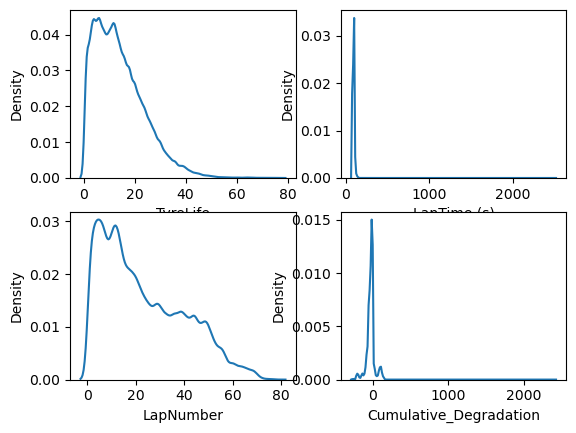

In [258]:
fig, axes = plt.subplots(2,2)

sns.kdeplot(F1_clean["TyreLife"], ax=axes[0,0])
sns.kdeplot(F1_clean["LapTime (s)"], ax=axes[0,1])
sns.kdeplot(F1_clean["LapNumber"], ax=axes[1,0])
sns.kdeplot(F1_clean["Cumulative_Degradation"], ax=axes[1,1])

plt.show()

<Axes: ylabel='Density'>

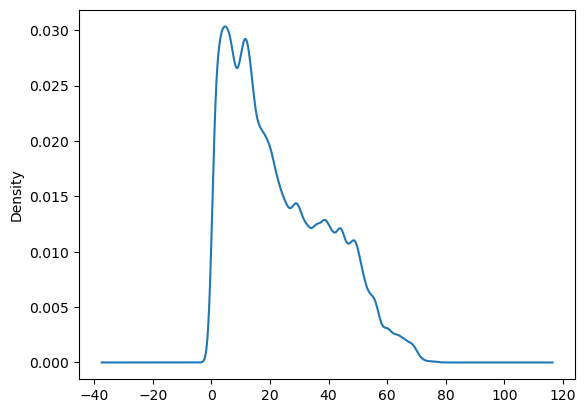

In [32]:
source['LapNumber'].plot.density()